# LLM Administrative Task Benchmark — SSPP
### Google Colab Edition

Benchmarks local LLMs on three SSPP-relevant administrative tasks: **QnA**, **Letter Generation**, and **Summarization**.

**Important note on Ground Truth:** the reference answers used in this notebook were **authored and validated** for this project (realistic but synthetic SSPP-style examples).. Replace `data/*.json` with real anonymized SSPP examples once available — the rest of the pipeline works unchanged.

---
## 1. Setup — Install Ollama inside Colab


In [4]:
# Install the missing zstd compression tool
!sudo apt-get update && sudo apt-get install -y zstd
# Install Ollama inside the Colab VM
!curl -fsSL https://ollama.com/install.sh | sh


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cli.github.com/packages stable/main amd64 Packages [354 B]       
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,077 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,228 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,030 kB]
Hit:13 https

In [6]:
# Start the Ollama server in the background
import subprocess, time
ollama_process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(5)  # give the server a moment to start
print("Ollama server started.")


Ollama server started.


In [8]:
# Install Python dependencies
!pip install -q ollama rouge-score bert-score pandas matplotlib


## 2. Pull the models you want to benchmark

⚠️ Colab free tier has limited disk (~ 78 GB) and RAM (~12-13 GB). You can run
larger models here than on your local 8 GB machine — useful for comparing
against the 8 GB-tier models to see the quality ceiling.

Edit the list below to match what you want to test.


In [9]:
models_to_pull = [
    "qwen3.5:4b",
    "gemma4:e4b-it-q4_K_M",
    "phi4-mini",
    "mistral",
    # add more as needed, e.g. "qwen3.5:9b", "llama3.2:3b" check the csv file for the full list of available models to use 
]

for tag in models_to_pull:
    print(f"Pulling {tag} ...")
    !ollama pull {tag}


Pulling qwen3.5:4b ...

Pulling gemma4:e4b-it-q4_K_M ...

Pulling phi4-mini ...

Pulling mistral ...



## 3. Get the benchmark code and data

Option A: upload the `llm_benchmark` folder as a zip (recommended for Colab).
Option B: paste the ground truth JSON directly into cells (fallback, shown below
commented out) if you don't want to upload files.


In [11]:
# Option A: upload llm_benchmark.zip (containing data/ and src/ folders)
from google.colab import files
import zipfile, os

uploaded = files.upload()  # select llm_benchmark.zip when prompted

for fname in uploaded.keys():
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall(".")
        print(f"Extracted {fname}")

os.chdir("llm_benchmark")
print("Working directory:", os.getcwd())
!ls -la data/ src/


: 

## 4. Run benchmarks

Same CLI as local usage, just executed via `!python` in Colab cells.


In [ ]:
import sys
sys.path.insert(0, "src")


In [ ]:
import os
import warnings

# 1. Fix the HF Warning: Silence the unauthenticated request warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# 2. Fix 'UNEXPECTED' logs: Suppress transformer loading logs
import logging
from transformers import logging as tf_logging
tf_logging.set_verbosity_error()

print("Environment configured to suppress non-critical warnings.")

In [ ]:
# Run ALL tasks for ALL models listed in data/models.csv
!python src/run_all_benchmarks.py --all


In [ ]:
# --- Alternative: run a single model across all tasks ---
# !python src/run_all_benchmarks.py --model qwen3.5:4b

# --- Alternative: run a single task across all models ---
# !python src/run_all_benchmarks.py --all --tasks qna

# --- Alternative: run one task, one model directly ---
# !python src/benchmark_letter.py --model mistral


## 5. Load and analyze results
used matplotlib to visulaize some data preduced 

In [ ]:
import pandas as pd

df = pd.read_csv("results/all_results.csv")
df.head(10)


In [ ]:
# Average time and quality per model per task
summary = df.groupby(["task", "model"]).agg(
    avg_time_seconds=("time_seconds", "mean"),
    avg_rougeL_f1=("rougeL_f1", "mean"),
    avg_bertscore_f1=("bertscore_f1", "mean"),
    n_errors=("error", lambda x: (x != "").sum()),
).round(3).reset_index()

summary.sort_values(["task", "avg_bertscore_f1"], ascending=[True, False])


NameError: name 'summary' is not defined

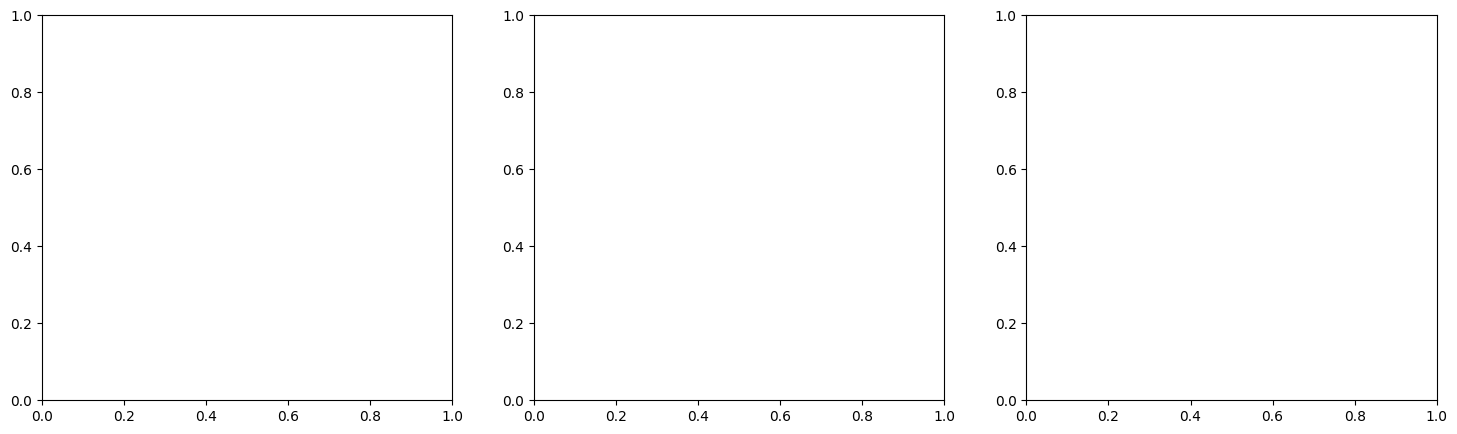

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, task in zip(axes, ["qna", "letter", "summary"]):
    sub = summary[summary["task"] == task].sort_values("avg_time_seconds")
    ax.barh(sub["model"], sub["avg_time_seconds"], color="#0D9E8B")
    ax.set_title(f"{task.upper()} — Avg generation time (s)")
    ax.set_xlabel("seconds")

plt.tight_layout()
plt.savefig("results/timing_comparison.png", dpi=150)
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, task in zip(axes, ["qna", "letter", "summary"]):
    sub = summary[summary["task"] == task].sort_values("avg_bertscore_f1")
    ax.barh(sub["model"], sub["avg_bertscore_f1"], color="#1EB89A")
    ax.set_title(f"{task.upper()} — Avg BERTScore F1")
    ax.set_xlabel("BERTScore F1")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("results/quality_comparison.png", dpi=150)
plt.show()


## 6. Inspect individual generations

Useful for spot-checking quality beyond the automated metrics — read a few
generated letters/answers/summaries directly to sanity-check the scores.


In [ ]:
# Look at one example in detail
import json

with open("results/letter/letter_Mistral-7B.json", encoding="utf-8") as f:
    data = json.load(f)

example = data["examples"][0]
print("QUERY:\n", example["query"])
print("\nGROUND TRUTH:\n", example["ground_truth"])
print("\nGENERATED:\n", example["generated"])
print("\nMETRICS:\n", example.get("metrics"))


## 7. Download results

Colab's filesystem is wiped between sessions — download your results before closing.


In [ ]:
from google.colab import files

files.download("results/all_results.csv")
files.download("results/timing_comparison.png")
files.download("results/quality_comparison.png")
